
# Example for I_RCK001

This python notebook follows the general workflow of the upper_american_calculate_rim_inflows.py, but is paired back to only calucate flows for Rock Creek.

Steps for Rock Creek
* Import input dataset used for the previous extension
* Unimpair flows for Rock Creek by adding back upstream diverted flows
* Extend the period of record using an s-curve disagg with FNF data for the American River Middle Fork CDEC data
* Calculate Rim Inflows (for Rock Creek this only requires rounding the unimpaired and extended gage data to two places after the decimal)


In [1]:
#%%

# Import needed packages and Extenion, Impairment, Rim Inflow, and Evaporation Functions

import os

os.chdir("../")

from extension_functions import *
from unimpairment_functions import *
from rim_inflow_functions import *
from evaporation_functions import *
import pandas as pd
import matplotlib.pyplot as plt

Update 's_old_spreadsheet_dir' to direct the code to the CS3_I_RCK001 excel spreadsheet, update the spreadsheet name as needed.

In [2]:
# file for comparison
s_old_spreadsheet_dir = 'Examples/' 
s_old_spreadsheet_fn = s_old_spreadsheet_dir + 'CS3_I_RCK001_Rev2022G.xlsm'

## Import Model Input Data
For this example we'll use the input dataset from the previous extension (through 2021) from the spreasheet. For rim watersheds in the Upper American, this data is included in the Inputs/Upper_american_2022_extension_data.csv.
Using these inputs will allows us to compare the python workflow results with the excel spreadsheet results.
i_final_year should be set to the end water year of the last extension (2021)

### To use an extended input dataset
You wil need to run upper_armerican_data_read.py to generate the updated model inputs. This script will develop an extended dataset saved here: /Intermediate/upper_american_full_gauge_data_wevap.csv that would then be imported in place of the previous extension dataset


In [3]:
i_final_year = 2021

# this holds the already extended evap rates
s_evap_dss_path = r".\Inputs\evaporation_rates.dss"

# option to plot comparison between python and excel workflows
b_compareData = True
s_prev_rim_inflows_fn = "Examples/CS3_Sac_ReadAllInflowDatatoDSS_05.18.23.xlsm" # file path and name must be provided to plot/calculate comparison
s_prev_rim_inflow_sheet = "Inflows"

# first if the needed output folders don't exist, create them
os.makedirs('./Intermediate', exist_ok=True)
os.makedirs('./Figures', exist_ok=True)
os.makedirs('./Outputs', exist_ok=True)

# read in the data that we already read in
df_full_data = pd.read_csv('./Inputs/upper_american_2022_extension_data.csv', index_col=0, parse_dates=True) # this will pull in the last extension dataset (through 2021) which matches the spreadsheets (w/ the exception of some minor corrected dataset errors)
df_full_data.replace(-901, np.nan, inplace=True) # set -901 to nan

# if using the extended dataset uncomment the line below
#df_full_data = pd.read_csv('./Intermediate/upper_american_full_gauge_data.csv', index_col=0, parse_dates=True) # this will read in the extended data set if you run upper_american_data_read.py


,11427400,11427500,11427700,11427750,11427200,AMF,11427760,11439501,11434900,11428000,...,Folsom Diversions,Folsom South Canal,Folsom,YB90,YB91,Folsom Fair Oaks,11443450,Folsom_evap,NAT_evap,11433930
1921-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.450,NaN,...,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1921-10-31,NaN,NaN,NaN,NaN,NaN,14.200,NaN,NaN,1.450,NaN,...,5.000000,0.000000,0.000,14.700000,NaN,0.070890,NaN,0.000,0.000000,0.000000
1921-11-30,NaN,NaN,NaN,NaN,NaN,38.800,NaN,NaN,0.000,NaN,...,5.000000,0.000000,0.000,14.900000,NaN,0.036033,NaN,0.000,0.000000,0.000000
1921-12-31,NaN,NaN,NaN,NaN,NaN,131.000,NaN,NaN,0.000,NaN,...,4.000000,0.000000,0.000,10.200000,NaN,3.070438,NaN,0.000,0.000000,0.000000
1922-01-31,NaN,NaN,NaN,NaN,NaN,112.700,NaN,NaN,0.000,NaN,...,4.000000,0.000000,0.000,9.500000,NaN,0.365099,NaN,0.000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-31,73.4,0.983802,2.318083,0.612417,0.099610,128.443,2.730050,25.492760,3.471,NaN,...,10.516364,1.047273,361.043,1.537190,NaN,0.059097,9.434,4.122,0.240000,1.074050
2021-06-30,71.3,0.660496,0.185058,0.164231,0.833058,32.390,1.303140,6.878678,4.051,NaN,...,11.038017,1.513388,288.402,1.491570,NaN,0.054029,8.849,4.388,0.285620,1.009587
2021-07-31,66.2,0.676364,0.034003,0.033572,2.502545,6.463,0.953058,4.310281,1.731,NaN,...,11.918678,1.676033,243.824,1.402314,NaN,0.057903,9.697,3.675,0.273719,0.902479
2021-08-31,58.5,0.657917,0.017401,0.017708,4.882116,0.000,0.873124,3.658512,0.930,NaN,...,10.754380,1.382479,233.573,1.120661,NaN,0.048427,8.802,2.836,0.232066,0.772760


## View Input Datasets
Rock Creek uses data for three stations. 
* USGS 11444201 Rock Creek Near Placerville is the station used to represent flows for this CalSim Inflow location
* USGS 11444280 Is the powerhouse diversion above the Rock Creek gage. To unimpair flows at the Rock Creek gage, we'll need to add this diversion back to the gage data. 
* CDEC FNF for the American River at Folsom Lake (AMF) covers the full period of record and will be used to extend the unimpaired flows

We'll plot the data to look at the available period of record

<Axes: >

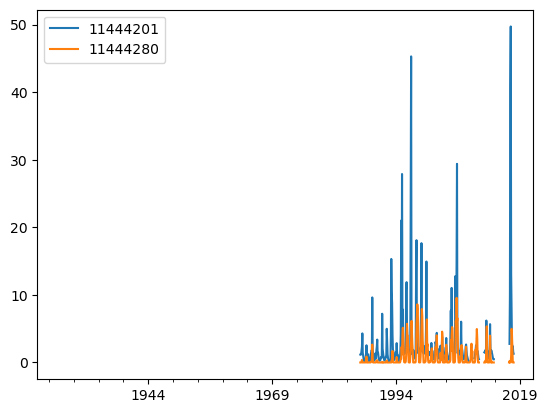

In [4]:
# stations used for Rock Creek
sl_usgs_stations = ['11444201','11444280']
sl_cdec_stations = ['AMF']

# plot data for location
fig,ax = plt.subplots()
#df_full_data[sl_cdec_stations].plot(ax=ax)
df_full_data[sl_usgs_stations].plot(ax=ax)
#plt.ylim(0,60)


A plot of the gage data, shows roughly 25 years of available data with signficant gaps
No gapfilling or evaporation datasets are used for this inflow location

## Unimpair the gage data
Each unimpaired flow location has it's own function related to the gage number, 'unimpaired_11444201' in the 'unimpairment_functions.py' file is used for the Rock Creek unimpairment. For Rock Creek unimpairment we need to add back flows diverted to the Rock Creek Powerhouse, this data is provided by USGS 11444280

We'll also want to remove any negative flow values after the unimpairment. the 'remove_negatives_timeseries' function redistributes negative values proporitionally over other months in the water year to maintain the annual volume at the gage.


[]

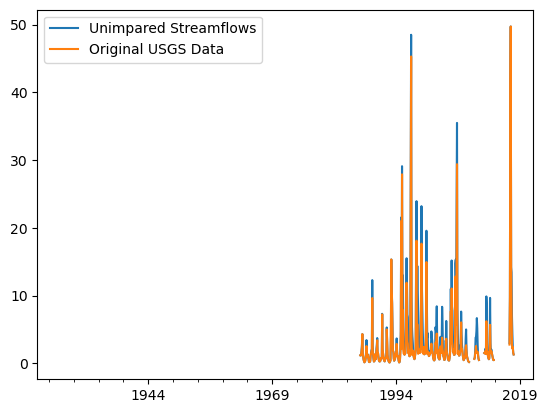

In [5]:

### unimpairing the data
df_unimpaired_data = pd.DataFrame()

df_unimpaired_data['11444201'] = unimpaired_11444201(df_full_data)

# drop the first row which is only for calculating storage differences
df_unimpaired_data.drop(index=df_unimpaired_data.index[0], inplace=True)

# redistribute negatives
df_pos_unimpaired_data = remove_negatives_timeseries(df_unimpaired_data)

# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_unimpaired_data[sl_usgs_stations[0]].plot(ax=ax,label='unimpared')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['Unimpared Streamflows','Original USGS Data'])
plt.plot()

The unimpaired flows are greater than the original gage flows, as expected with the addition of the 11444280 flows

## Compare the unimpaired flows from the python workflow with the old excel spreadsheet to verify 
Unimpaired gage data is included in the I_RCK001 spreadsheet, on the 'UNIMP Rock Creek 11444201' sheet

In [6]:
# confirm unimpairment matches spreadsheet values

s_sheet = 'UNIMP Rock Creek 11444201' 
df_excel_unimpaired = pd.read_excel(s_old_spreadsheet_fn,
                                    sheet_name = s_sheet,
                                    skiprows= 14,
                                    usecols='B:D',
                                    index_col=0)
df_combined_unimpaired = pd.concat([df_unimpaired_data,df_excel_unimpaired], axis=1)
df_combined_unimpaired['diff'] = df_combined_unimpaired['11444201'] - df_combined_unimpaired['TAF']

print(f'Maximum Difference Between Datasets: {df_combined_unimpaired['diff'].max()}'  )

Maximum Difference Between Datasets: 4.247937113177613e-09


Maximum difference between the datasets is very small and just a rounding difference between python and excel

## Extend the Dataset
Use data from FNF on the American River from CDEC (Station AMF). We'll use the unimpaired data from 1987 to 2008 to do the s-curve dissag w/ the AMF data. 
We also have data for the USGS gage for the end of wy 2017, so while this time period won't be used to develop the s-curve disagg, we'll keep it for the final extended unimpaired dataset (second line overwritting the extended data with the original unimpaired flows)



Extending flows...


[]

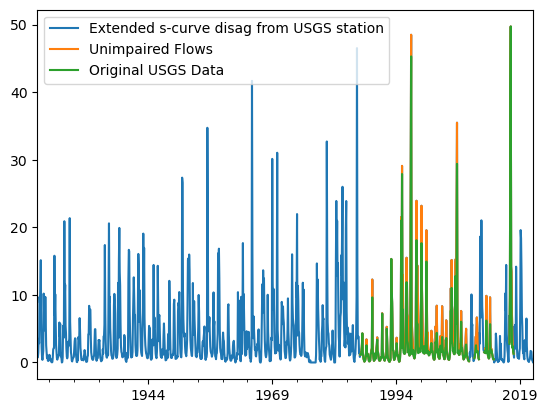

In [7]:
df_extended_data = pd.DataFrame()
df_synthetic_data = pd.DataFrame()

print("Extending flows...")

# extend all with the s-curve disaggregation
extend_data(df_full_data['AMF'], df_unimpaired_data['11444201'], df_extended_data, df_synthetic_data, 1987, 2008, True, '11444201', i_final_year=i_final_year)
# replace the end of wy 2017
df_extended_data.loc[datetime(2016, 11, 30): datetime(2017, 9, 30), '11444201'] = df_unimpaired_data.loc[datetime(2016, 11, 30): datetime(2017, 9, 30), '11444201']


# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_extended_data[sl_usgs_stations[0]].plot(ax=ax,label='extended s-curve disagg')
df_unimpaired_data[sl_usgs_stations[0]].plot(ax=ax,label='unimpared')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['Extended s-curve disag from USGS station','Unimpaired Flows','Original USGS Data'])
plt.plot()

### Compare with spreadsheet extended dataset

In [8]:
# confirm disaggregation matches spreadsheet values

# confirm unimpairment matches spreadsheet values
s_sheet = 'MODELA' # sheet with scurve dissag
df_excel_scurve = pd.read_excel(s_old_spreadsheet_fn,
                                    sheet_name = s_sheet,
                                    skiprows= 7,
                                    usecols='AF:AG',
                                    index_col = 0)
df_combined_scurve = pd.concat([df_extended_data,df_excel_scurve], axis=1)
df_combined_scurve['diff'] = df_combined_scurve['11444201'] - df_combined_scurve['TAF']

print(df_combined_scurve.head())
print(f'Maximum Difference Between Datasets: {df_combined_unimpaired['diff'].max()}'  )

            11444201       TAF          diff
1921-10-31  0.796292  0.796292  8.737899e-12
1921-11-30  1.443420  1.443420  4.894840e-11
1921-12-31  3.488787  3.488787  5.247891e-11
1922-01-31  2.843710  2.843710  2.047695e-11
1922-02-28  9.713949  9.713949  2.175629e-10
Maximum Difference Between Datasets: 4.247937113177613e-09


Again the maximum difference is very small and just a rounding difference

## Calculate Rim Inflows
The python code calls a location specific Rim Inflow function (here tied to the Inflow location abbreviation I_RCK001), included in rim_inflow_functions.py  
For this location, the inflow timeseries is set to the the extended unimpaired flows rounded to two decimal places. Other locations are more complex and often require removing upstream inflow locations or scaling based on basin areas 

Calculating rim inflows...


[]

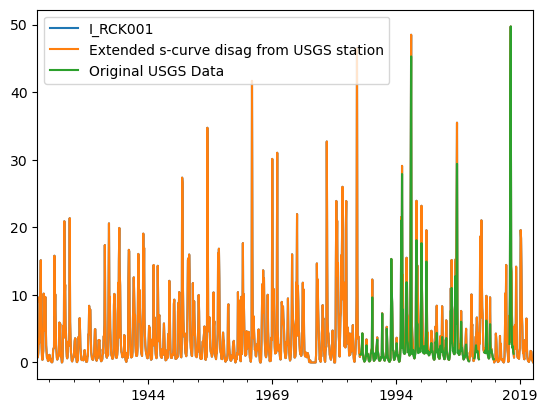

In [9]:
# final rim inflows
df_rim_inflows = pd.DataFrame()

print("Calculating rim inflows...")

I_RCK001(df_extended_data, df_rim_inflows)


# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_rim_inflows['I_RCK001'].plot(ax=ax,label='I_RCK001')
df_extended_data[sl_usgs_stations[0]].plot(ax=ax,label='extended s-curve disagg')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['I_RCK001','Extended s-curve disag from USGS station','Original USGS Data'])
plt.plot()

The extended, unimpaired data and I_RCK001 are are essentially the same

## Compare the python generated I_RCK001 Rim Inflow w/ the Previous Spreadsheet Dataset

In [10]:
# Compare with Previous Data
df_reference = pd.read_excel(s_prev_rim_inflows_fn, sheet_name=s_prev_rim_inflow_sheet, skiprows=[0,2,3,4,5,6,7,8,9,10,11],header=0, index_col=0, parse_dates=True)
df_diffs = abs(df_reference[df_rim_inflows.columns] - df_rim_inflows).max().to_frame('Max Difference')
df_diffs['Median Value - Original'] = df_reference[df_rim_inflows.columns].mean()
df_diffs['Median Value - Extension'] = df_rim_inflows.mean()

df_diffs['Max Percent Difference'] = (abs(df_reference[df_rim_inflows.columns] - df_rim_inflows)).max() / df_reference[df_rim_inflows.columns].mean()*100
print("Maximum differences:")
print(df_diffs.sort_values(by='Max Difference', ascending=False).to_string())

Maximum differences:
          Max Difference  Median Value - Original  Median Value - Extension  Max Percent Difference
I_RCK001             0.0                 4.044767                  4.044767                     0.0


The Maximum percent difference between the dataset is zero. No change from the spreadsheet to the python generated output.